# Superstore Sales Analytics - Interview Presentation Notebook

This notebook is designed for portfolio and interview storytelling.

Structure:
1. Business problem
2. Data preparation
3. 8 strongest visuals
4. 5 key insights
5. 3 business recommendations
6. ML prediction summary
7. Executive conclusion

## 1) Problem Statement

Superstore wants to improve profitability while maintaining revenue growth.

Questions:
- Which areas drive sales and profit?
- Which areas create losses?
- What role does discount play in profit erosion?
- Can we predict order-level profit with ML?

In [2]:
import warnings  # Suppress warning messages for cleaner output
warnings.filterwarnings('ignore')

import numpy as np  # Numerical operations and array handling
import pandas as pd  # Data manipulation and analysis (DataFrames)
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns  # Statistical data visualization, built on matplotlib

from pathlib import Path  # Object-oriented filesystem paths

# Scikit-learn modules for machine learning pipeline
from sklearn.model_selection import train_test_split  # Split data into train/test sets
from sklearn.compose import ColumnTransformer  # Apply transformers to columns
from sklearn.pipeline import Pipeline  # Build ML pipelines
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Encode categories, scale features
from sklearn.impute import SimpleImputer  # Handle missing values
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Model evaluation metrics
from sklearn.linear_model import LinearRegression  # Linear regression model
from sklearn.ensemble import RandomForestRegressor  # Random forest regression model

pd.set_option('display.max_columns', 200)  # Show more columns in DataFrame display
sns.set_theme(style='whitegrid', palette='Set2')  # Set seaborn plot style and color palette

## 2) Data Preparation (Simple -> Advanced)

We will do preparation in clear steps:
1. Load dataset
2. Preview dataframe and shape
3. Check dtypes, missing values, and duplicates
4. Transform columns and create analysis-ready fields

In [4]:
candidate_paths = [
    Path('SuperStoreOrders_SuperStoreOrders.csv'),
    Path('../SuperStoreOrders_SuperStoreOrders.csv'),
    Path('data/raw/SuperStoreOrders_SuperStoreOrders.csv')
]

# NOTE: This notebook uses the corrected CLEAN dataset with all valid records retained.
# Data engineering decisions:
#   - Keep all 51,290 valid business rows (no duplicate-row deletion required)
#   - Remove only spreadsheet artifacts (empty padding rows and Unnamed summary columns)
#   - Repair mixed date formats using robust parsing (default + dayfirst fallback)
#   - Standardize schema to clean lowercase_underscore columns

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('CSV not found. Update candidate_paths.')

raw_df = pd.read_csv(data_path)
df = raw_df.copy()

for dcol in ['order_date', 'ship_date']:
    if dcol in df.columns:
        p1 = pd.to_datetime(df[dcol], errors='coerce')
        p2 = pd.to_datetime(df[dcol], errors='coerce', dayfirst=True)
        df[dcol] = p1.fillna(p2)

print('Loaded from:', data_path)
print('Raw shape:', df.shape)
print('Duplicate rows:', int(df.duplicated().sum()))
print(f'Date range: {df["order_date"].min()} to {df["order_date"].max()}')

Loaded from: ..\SuperStoreOrders_SuperStoreOrders.csv
Raw shape: (51290, 22)
Duplicate rows: 0
Date range: 2011-01-01 00:00:00 to 2014-12-31 00:00:00


### Step 2.1: Preview dataframe and shape

In [5]:
print('Current shape:', df.shape)
display(df.head())

Current shape: (51290, 22)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Algeria,Constantine,Africa,Africa,OFF-TEN-10000025,"Tenex Lockers, Blue",Office Supplies,Storage,408,2.0,0.0,106.140,35.46,Medium,2011.0,1.0
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,OFF-SU-10000618,"Acme Trimmer, High Speed",Office Supplies,Supplies,120,3.0,0.1,36.036,9.72,Medium,2011.0,2.0
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Hungary,Budapest,EMEA,EMEA,OFF-TEN-10001585,"Tenex Box, Single Width",Office Supplies,Storage,66,4.0,0.0,29.640,8.17,High,2011.0,3.0
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Sweden,Stockholm,EU,North,OFF-PA-10001492,"Enermax Note Cards, Premium",Office Supplies,Paper,45,3.0,0.5,-26.055,4.82,High,2011.0,4.0
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings,114,5.0,0.1,37.770,4.70,Medium,2011.0,5.0


### Step 2.2: Basic quality checks (dtypes, missing, duplicates)

In [7]:
display(df.dtypes.to_frame('dtype').T)

missing_counts_raw = df.isna().sum().sort_values(ascending=False)
missing_columns_raw = missing_counts_raw[missing_counts_raw > 0]
print('Total missing cells (raw):', int(missing_counts_raw.sum()))
if not missing_columns_raw.empty:
    missing_df_raw = missing_columns_raw.to_frame('missing_count')
    missing_df_raw['missing_pct'] = (missing_df_raw['missing_count'] / len(df) * 100).round(2)
    display(missing_df_raw)
else:
    print('No missing values found in raw view.')

dup_raw = int(df.duplicated().sum())
print('Duplicate rows (raw):', dup_raw)

df_nodup = df.drop_duplicates().copy()
missing_counts_nodup = df_nodup.isna().sum().sort_values(ascending=False)
missing_columns_nodup = missing_counts_nodup[missing_counts_nodup > 0]
print('Rows after dedup (for analysis):', len(df_nodup))
print('Total missing cells (deduped):', int(missing_counts_nodup.sum()))
if not missing_columns_nodup.empty:
    missing_df_nodup = missing_columns_nodup.to_frame('missing_count')
    missing_df_nodup['missing_pct'] = (missing_df_nodup['missing_count'] / len(df_nodup) * 100).round(2)
    display(missing_df_nodup)
else:
    print('No missing values found after removing duplicates.')

,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number
dtype,object,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,object,object,int64,float64,float64,float64,float64,object,float64,float64


Total missing cells (raw): 0
No missing values found in raw view.
Duplicate rows (raw): 0
Rows after dedup (for analysis): 51290
Total missing cells (deduped): 0
No missing values found after removing duplicates.


### Step 2.3: Transform columns for analysis and modeling

In [8]:
df.columns = [c.strip().replace(' ', '_') for c in df.columns]

for col in df.columns:
    if 'date' in col.lower():
        df[col] = pd.to_datetime(df[col], errors='coerce')

df = df.drop_duplicates().copy()

alias_map = {
    'sales': 'Sales',
    'profit': 'Profit',
    'discount': 'Discount',
    'order_date': 'Order_Date',
    'ship_date': 'Ship_Date',
    'category': 'Category',
    'sub_category': 'Sub_Category',
    'segment': 'Segment',
    'region': 'Region',
    'state': 'State',
    'product_name': 'Product_Name',
    'customer_name': 'Customer_Name',
    'order_id': 'Order_ID'
}
for src, dst in alias_map.items():
    if src in df.columns and dst not in df.columns:
        df[dst] = df[src]

for num_col in ['Sales', 'Profit', 'Discount']:
    if num_col in df.columns:
        df[num_col] = pd.to_numeric(df[num_col], errors='coerce')

if 'Order_Date' in df.columns:
    df['Order_Year'] = df['Order_Date'].dt.year
    df['Order_Month'] = df['Order_Date'].dt.month

if {'Sales', 'Profit'}.issubset(df.columns):
    df['Profit_Margin'] = np.where(df['Sales'] != 0, df['Profit'] / df['Sales'], np.nan)

if 'Discount' in df.columns:
    bins = [-0.01, 0, 0.1, 0.2, 0.4, 1]
    labels = ['No Discount', 'Low', 'Medium', 'High', 'Very High']
    df['Discount_Bucket'] = pd.cut(df['Discount'], bins=bins, labels=labels)

print('Prepared shape:', df.shape)
display(df.head())

Prepared shape: (51290, 39)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number,Sales,Profit,Discount,Order_Date,Ship_Date,Category,Sub_Category,Segment,Region,State,Product_Name,Customer_Name,Order_ID,Order_Year,Order_Month,Profit_Margin,Discount_Bucket
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Algeria,Constantine,Africa,Africa,OFF-TEN-10000025,"Tenex Lockers, Blue",Office Supplies,Storage,408,2.0,0.0,106.140,35.46,Medium,2011.0,1.0,408,106.140,0.0,2011-01-01,2011-06-01,Office Supplies,Storage,Consumer,Africa,Constantine,"Tenex Lockers, Blue",Toby Braunhardt,AG-2011-2040,2011,1,0.260147,No Discount
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,OFF-SU-10000618,"Acme Trimmer, High Speed",Office Supplies,Supplies,120,3.0,0.1,36.036,9.72,Medium,2011.0,2.0,120,36.036,0.1,2011-01-01,2011-08-01,Office Supplies,Supplies,Consumer,Oceania,New South Wales,"Acme Trimmer, High Speed",Joseph Holt,IN-2011-47883,2011,1,0.300300,Low
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Hungary,Budapest,EMEA,EMEA,OFF-TEN-10001585,"Tenex Box, Single Width",Office Supplies,Storage,66,4.0,0.0,29.640,8.17,High,2011.0,3.0,66,29.640,0.0,2011-01-01,2011-05-01,Office Supplies,Storage,Consumer,EMEA,Budapest,"Tenex Box, Single Width",Annie Thurman,HU-2011-1220,2011,1,0.449091,No Discount
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Sweden,Stockholm,EU,North,OFF-PA-10001492,"Enermax Note Cards, Premium",Office Supplies,Paper,45,3.0,0.5,-26.055,4.82,High,2011.0,4.0,45,-26.055,0.5,2011-01-01,2011-05-01,Office Supplies,Paper,Home Office,North,Stockholm,"Enermax Note Cards, Premium",Eugene Moren,IT-2011-3647632,2011,1,-0.579000,Very High
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings,114,5.0,0.1,37.770,4.70,Medium,2011.0,5.0,114,37.770,0.1,2011-01-01,2011-08-01,Furniture,Furnishings,Consumer,Oceania,New South Wales,"Eldon Light Bulb, Duo Pack",Joseph Holt,IN-2011-47883,2011,1,0.331316,Low


## 3) Strong Visual 1: Monthly Sales Trend

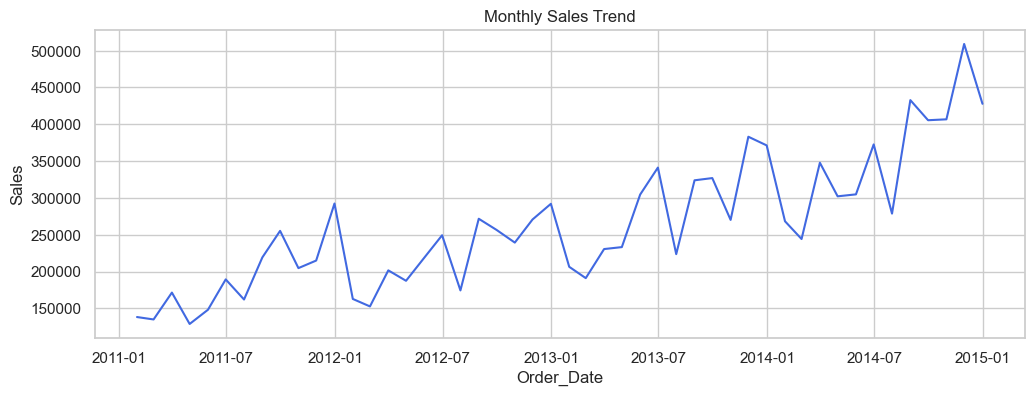

In [9]:
if {'Order_Date', 'Sales'}.issubset(df.columns):
    monthly_sales = df.set_index('Order_Date').resample('M')['Sales'].sum().reset_index()
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=monthly_sales, x='Order_Date', y='Sales', color='royalblue')
    plt.title('Monthly Sales Trend')
    plt.show()

## 4) Strong Visual 2: Monthly Profit Trend

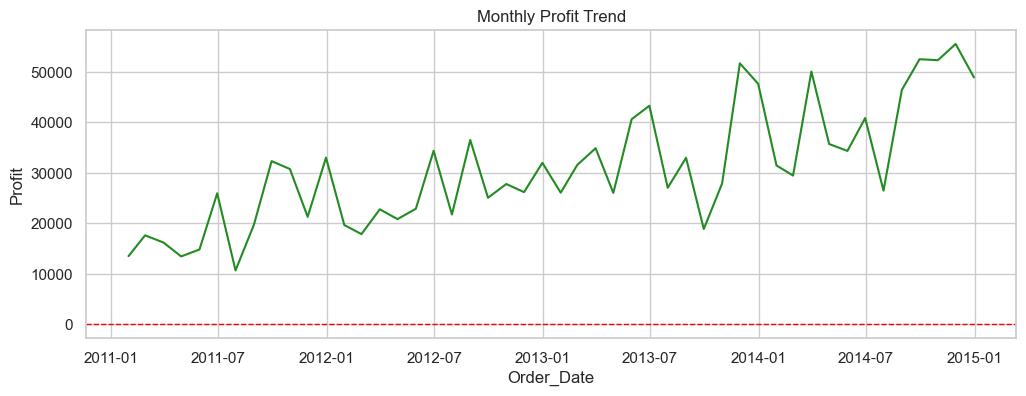

In [30]:
if {'Order_Date', 'Profit'}.issubset(df.columns):
    monthly_profit = df.set_index('Order_Date').resample('M')['Profit'].sum().reset_index()
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=monthly_profit, x='Order_Date', y='Profit', color='forestgreen')
    plt.title('Monthly Profit Trend')
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.show()

## 5) Strong Visual 3: Sales by Category

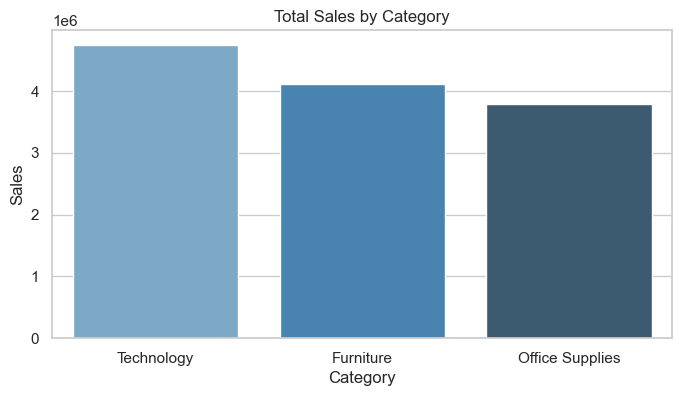

In [10]:
if {'Category', 'Sales'}.issubset(df.columns):
    cat_sales = df.groupby('Category', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=cat_sales, x='Category', y='Sales', palette='Blues_d')
    plt.title('Total Sales by Category')
    plt.show()

## 6) Strong Visual 4: Profit by Category

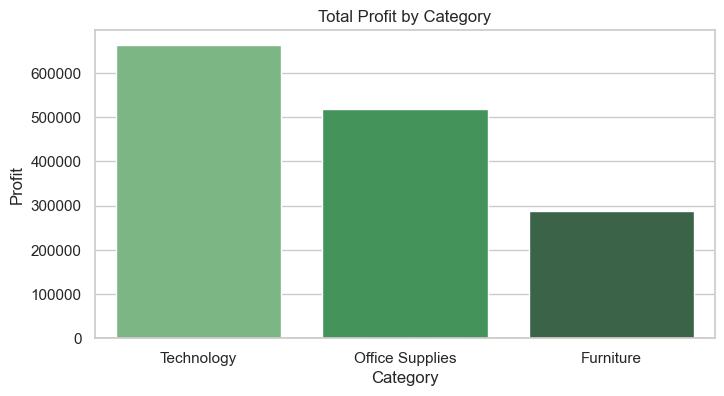

In [11]:
if {'Category', 'Profit'}.issubset(df.columns):
    cat_profit = df.groupby('Category', as_index=False)['Profit'].sum().sort_values('Profit', ascending=False)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=cat_profit, x='Category', y='Profit', palette='Greens_d')
    plt.title('Total Profit by Category')
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.show()

## 7) Strong Visual 5: Profit by Sub-Category (Worst to Best)

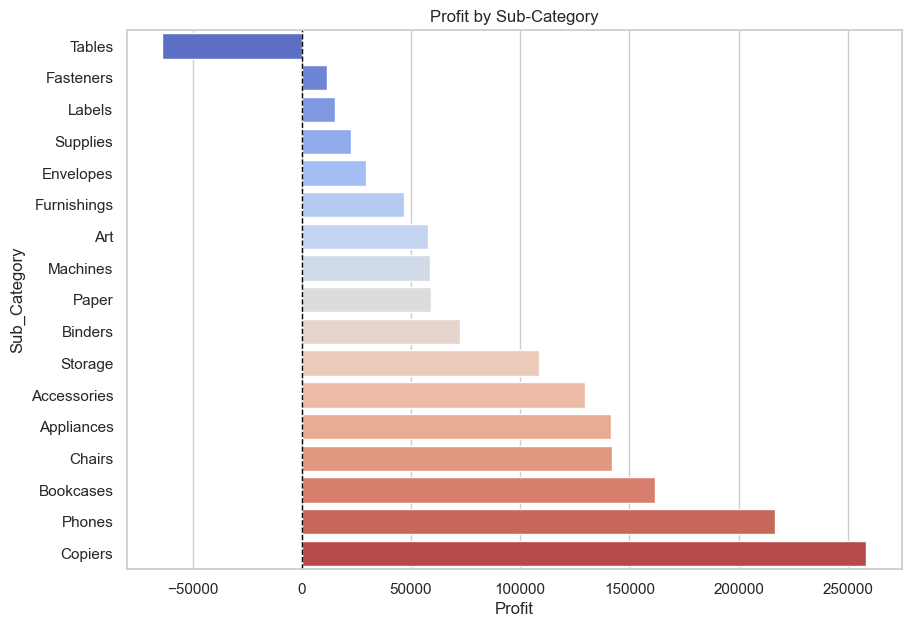

In [12]:
if {'Sub_Category', 'Profit'}.issubset(df.columns):
    sub_profit = df.groupby('Sub_Category', as_index=False)['Profit'].sum().sort_values('Profit')
    plt.figure(figsize=(10, 7))
    sns.barplot(data=sub_profit, y='Sub_Category', x='Profit', palette='coolwarm')
    plt.title('Profit by Sub-Category')
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.show()

## 8) Strong Visual 6: Region Performance (Sales and Profit)

,Region,Sales,Profit
3,Central,2822399,311403.98164
10,South,1600960,140355.76618
7,North,1248192,194597.95252
9,Oceania,1100207,121666.64200
11,Southeast Asia,884438,17852.32900
8,North Asia,848349,165578.42100
5,EMEA,806184,43897.97100
0,Africa,783776,88871.63100
4,Central Asia,752839,132480.18700
12,West,725514,108418.44890


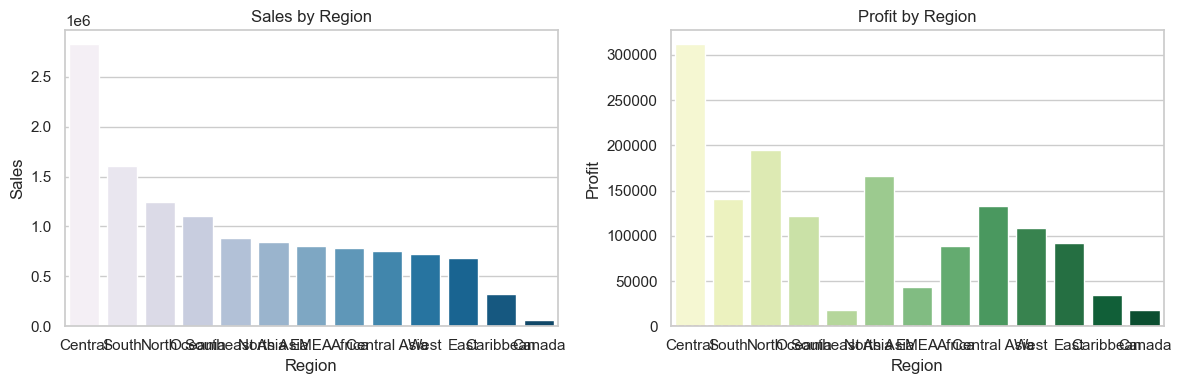

In [13]:
if {'Region', 'Sales', 'Profit'}.issubset(df.columns):
    region_perf = df.groupby('Region', as_index=False)[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    display(region_perf)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=region_perf, x='Region', y='Sales', ax=axes[0], palette='PuBu')
    axes[0].set_title('Sales by Region')

    sns.barplot(data=region_perf, x='Region', y='Profit', ax=axes[1], palette='YlGn')
    axes[1].set_title('Profit by Region')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

## 9) Strong Visual 7: Discount vs Profit

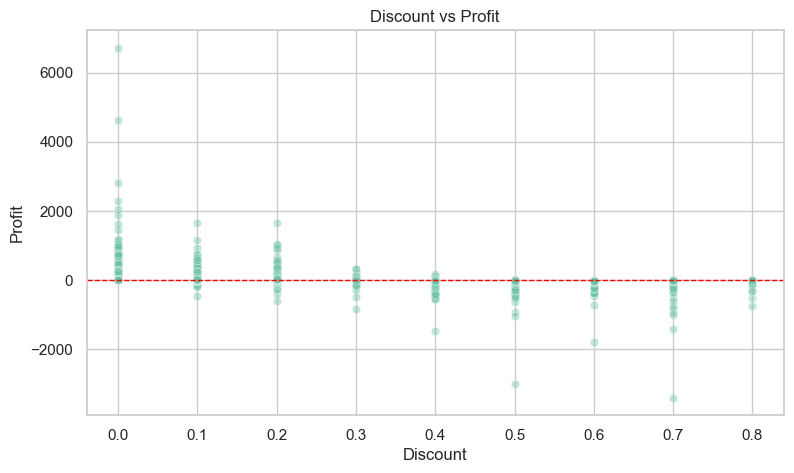

In [14]:
if {'Discount', 'Profit'}.issubset(df.columns):
    sample_df = df.sample(min(5000, len(df)), random_state=42)
    plt.figure(figsize=(9, 5))
    sns.scatterplot(data=sample_df, x='Discount', y='Profit', alpha=0.4)
    plt.title('Discount vs Profit')
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.show()

## 10) Strong Visual 8: Average Profit by Discount Bucket

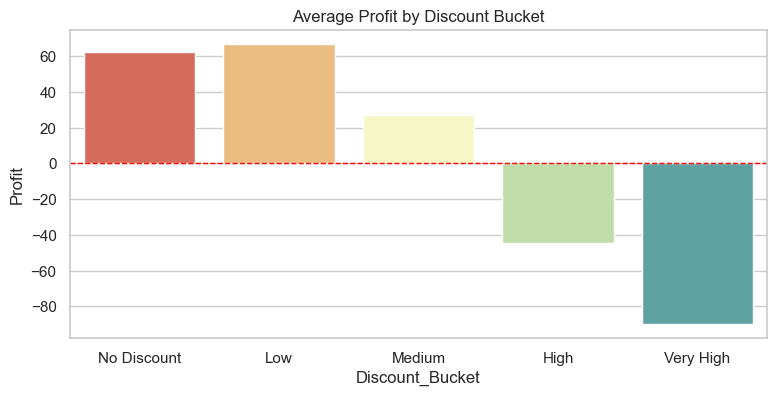

,Discount_Bucket,Profit
0,No Discount,62.051980
1,Low,66.806593
2,Medium,27.341183
3,High,-44.719241
4,Very High,-89.832373


In [15]:
if {'Discount_Bucket', 'Profit'}.issubset(df.columns):
    bucket_profit = df.groupby('Discount_Bucket', observed=False)['Profit'].mean().reset_index()
    plt.figure(figsize=(9, 4))
    sns.barplot(data=bucket_profit, x='Discount_Bucket', y='Profit', palette='Spectral')
    plt.title('Average Profit by Discount Bucket')
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.show()
    display(bucket_profit)

## 11) Machine Learning Snapshot (Predict Profit)

This section gives one clean, interview-ready regression pipeline.

,Model,MAE,RMSE,R2
1,RandomForestRegressor,2.383622,64.757456,0.865234
0,LinearRegression,52.731664,146.386239,0.311348


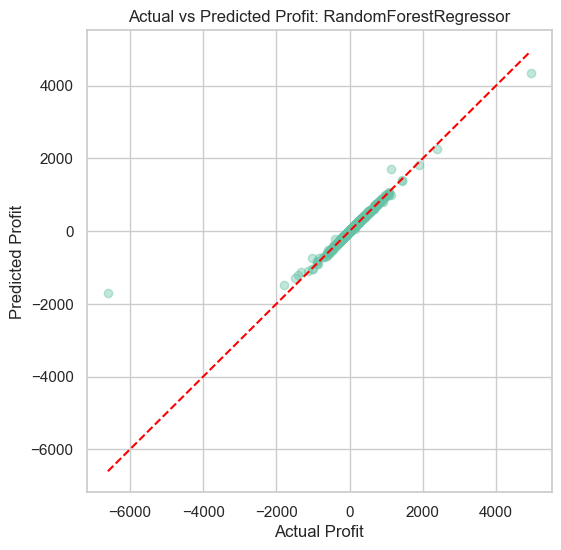

Dropped high-cardinality columns: ['order_date', 'ship_date', 'state', 'Order_Date', 'Ship_Date', 'State'] 
FAST_MODE: True


In [16]:
profit_target = 'Profit' if 'Profit' in df.columns else ('profit' if 'profit' in df.columns else None)
if profit_target is None:
    raise ValueError('Profit/profit column required for ML section.')

# Fast-mode switches for quick interview demo runs.
FAST_MODE = True
MAX_TRAIN_ROWS = 30000

ml_df = df.copy()
drop_candidates = [
    'Profit', 'profit',
    'Row_ID', 'row_id', 'S_no',
    'Order_ID', 'order_id',
    'Customer_ID', 'customer_id',
    'Customer_Name', 'customer_name',
    'Product_Name', 'product_name',
    'Product_ID', 'product_id',
    'Unnamed:_29', 'Unnamed:_30', 'Unnamed:_31',
    'year'
 ]
drop_cols = [c for c in drop_candidates if c in ml_df.columns]

X = ml_df.drop(columns=drop_cols, errors='ignore')
y = ml_df[profit_target]

mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

if FAST_MODE and len(X) > MAX_TRAIN_ROWS:
    sampled_idx = X.sample(n=MAX_TRAIN_ROWS, random_state=42).index
    X = X.loc[sampled_idx].copy()
    y = y.loc[sampled_idx].copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

high_card_cols = [c for c in cat_cols if X[c].nunique(dropna=True) > 300]
if high_card_cols:
    X = X.drop(columns=high_card_cols)
    cat_cols = [c for c in cat_cols if c not in high_card_cols]

for col in cat_cols:
    X[col] = X[col].astype('string').fillna('missing').astype('category')

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_trees = 60 if FAST_MODE else 250
models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=rf_trees,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
}

ml_results = []
pred_store = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    ml_results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    })
    pred_store[name] = pred

ml_results_df = pd.DataFrame(ml_results).sort_values('R2', ascending=False)
display(ml_results_df)

best_name = ml_results_df.iloc[0]['Model']
best_pred = pred_store[best_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.4)
low = min(y_test.min(), best_pred.min())
high = max(y_test.max(), best_pred.max())
plt.plot([low, high], [low, high], 'r--')
plt.title('Actual vs Predicted Profit: ' + best_name)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.show()
print('Dropped high-cardinality columns:', high_card_cols[:8], '...' if len(high_card_cols) > 8 else '')
print('FAST_MODE:', FAST_MODE)

## 12) Five Key Insights

1. The strongest revenue driver is **Technology** (highest total sales by category).

2. The strongest profit driver is **Technology** (highest total profit by category).

3. The largest profit leak is in **Tables** (worst sub-category profit).

4. High discount tiers show **negative** impact on average profit (profit turns negative for high/very high discounts).

5. Best ML model for profit prediction is **RandomForestRegressor** with R² = **0.87** (MAE: 2.38, RMSE: 64.76, FAST_MODE: True).

## 13) Three Business Recommendations

1. Build discount guardrails for products/sub-categories with repeated losses.

2. Focus inventory and marketing on high-profit segments and regions.

3. Use ML score as an order-risk signal before pricing finalization.

## 14) Executive Conclusion

This analysis identifies where Superstore earns and where it loses profit.

The visuals reveal business patterns, and the ML model provides predictive support.

Together, they enable data-driven pricing, product focus, and profitability improvement.